## Setup

In [ ]:
import os
import sys
import torch
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from ast import literal_eval
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)

current = os.getcwd()
parent = os.path.dirname(current)
sys.path.append(parent) 

converters = {
    "Word": str, 
    "Phonemes": literal_eval, 
    "No_Stress": literal_eval,
}

from swp.utils.setup import seed_everything, set_device
from swp.utils.models import get_model
from swp.utils.embeddings import create_embeddings_LSTM_hook
from swp.datasets.phonemes import get_phoneme_testloader
from swp.test.repetition import test
from swp.utils.datasets import enrich_for_plotting
from swp.viz.embeddings import dendro_dmatrix
from swp.viz.embeddings import mlem_importance, mlem_phonemes

# Set random seed and device
seed_everything(42)
device = set_device()

# Suppress warnings for nested tensors
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message="The PyTorch API of nested tensors is in prototype stage",
)

Using MPS device


### Load Model

In [2]:
# Load the model
model_name = "Ua_LSTM_h128_l1_v42_d0.0_t0.0_s1"
weights_path = "weights/75.pth"
batch_size = 2048

model = get_model(model_name)
model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
model.to(device)

Unimodel(
  (encoder): EncoderLSTM(
    (embedding): Embedding(42, 128)
    (dropout): Dropout(p=0.0, inplace=False)
    (recurrent): LSTM(128, 128, batch_first=True)
  )
  (decoder): DecoderLSTM(
    (embedding): Embedding(42, 128)
    (dropout): Dropout(p=0.0, inplace=False)
    (recurrent): LSTM(128, 128, batch_first=True)
  )
)

## Evaluation

In [3]:
# Evaluate on the Word Feature Evaluation Dataset
wfe_df = pd.read_csv("data/wfe.csv", converters=converters, index_col=0)
wfe_loader = get_phoneme_testloader(batch_size=batch_size, dataset_df=wfe_df)
wfe_results, _ = test(
    model=model,
    device=device,
    test_df=wfe_df,
    test_loader=wfe_loader,
)
wfe_results = enrich_for_plotting(wfe_results)
wfe_results.to_csv("data/wfe_enriched.csv")

# Evaluate on the Sonority Sequencing Principle Dataset
ssp_df = pd.read_csv("data/ssp.csv", converters=converters, index_col=0)
ssp_loader = get_phoneme_testloader(batch_size=batch_size, dataset_df=ssp_df)
ssp_results, _ = test(
    model=model,
    device=device,
    test_df=ssp_df,
    test_loader=ssp_loader,
)
ssp_results = enrich_for_plotting(ssp_results)
ssp_results.to_csv("data/ssp_enriched.csv")

### Figure 2A-D

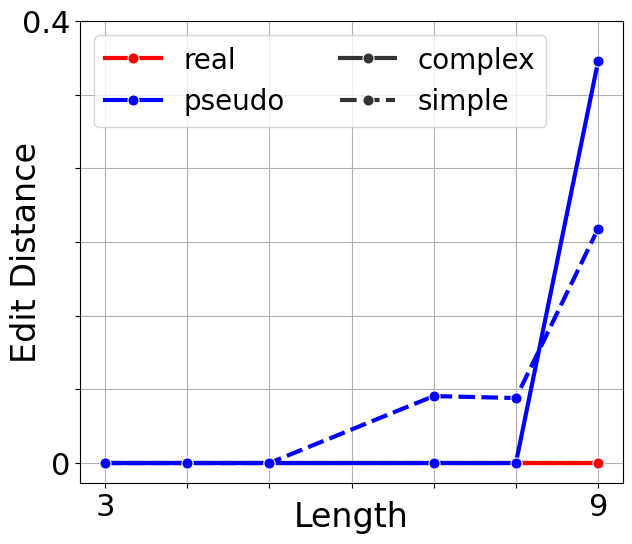

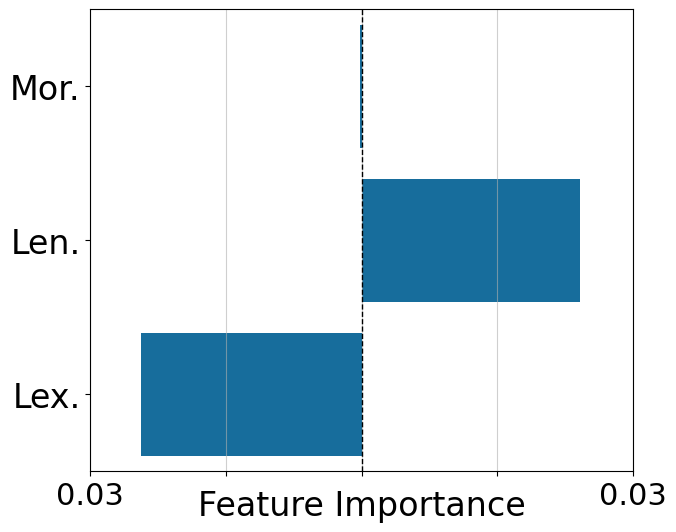

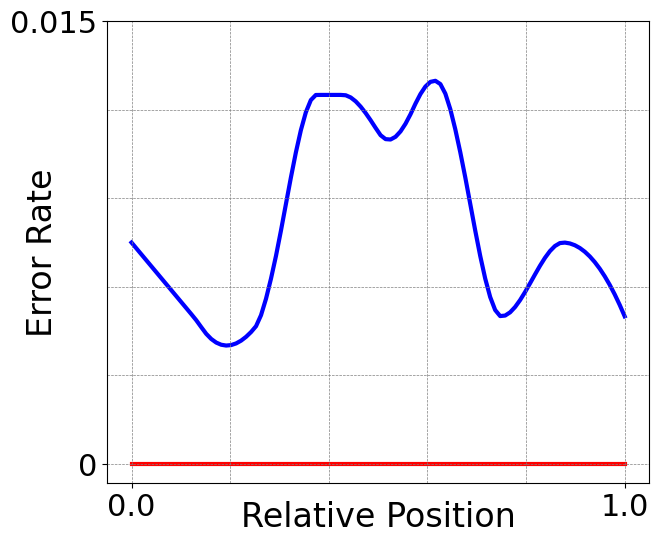

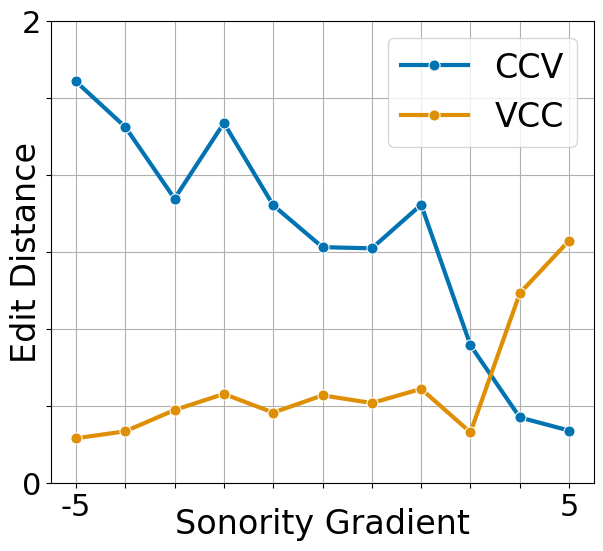

In [4]:
from swp.viz.test.length import plot_length_errors
from swp.viz.test.regressions import regression_plots
from swp.viz.test.position import plot_position_errors_smooth
from swp.viz.test.sonority import plot_sonority_errors

plot_length_errors(wfe_results)
regression_plots(wfe_results)
plot_position_errors_smooth(wfe_results)
plot_sonority_errors(ssp_results)

### Figure 3A-B

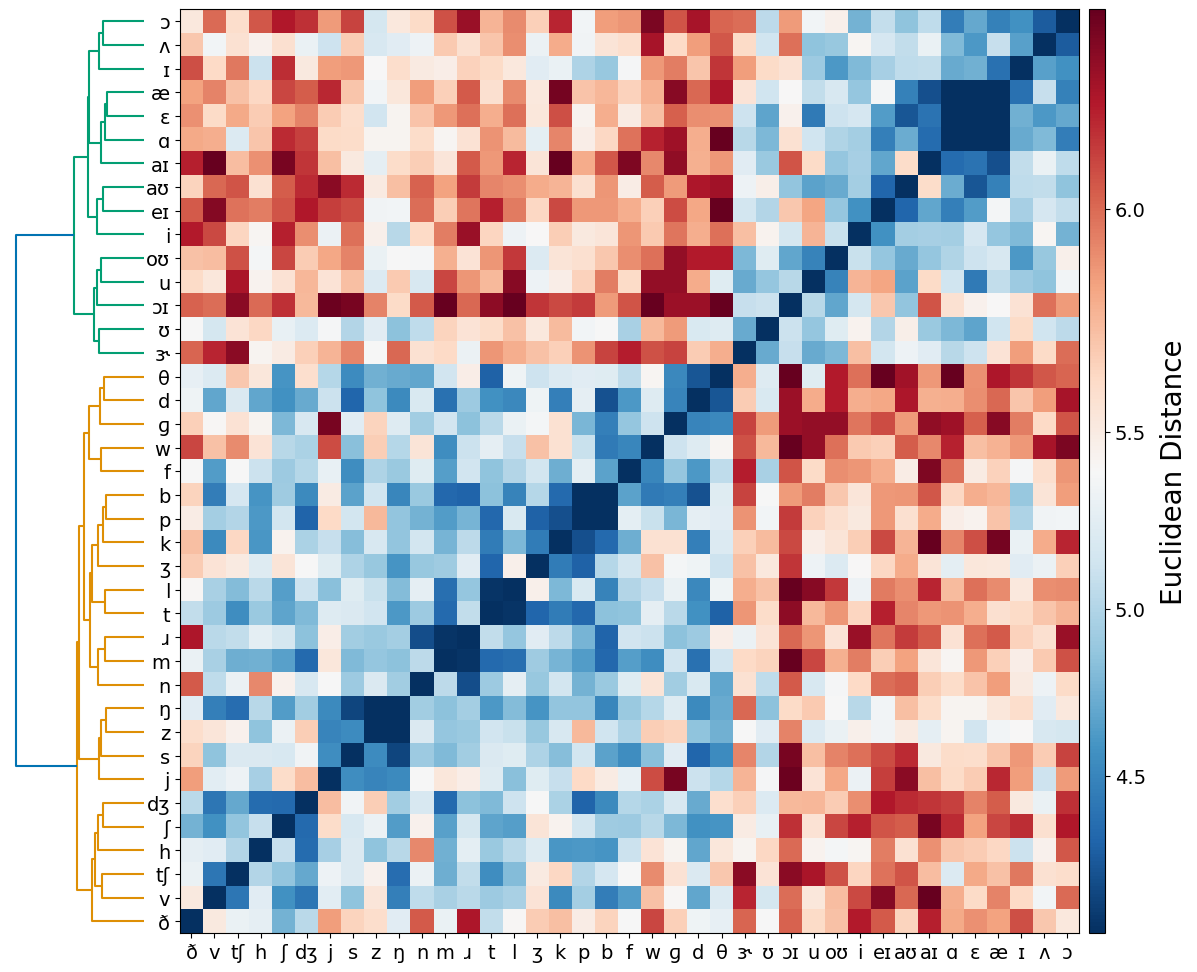

In [5]:
# Create hook to extract embeddings
buffer = {"Hidden": [], "Cell": []}
hook = create_embeddings_LSTM_hook(buffer)
hook_handle = model.encoder.recurrent.register_forward_hook(hook)

# Evaluate on the Single Phonemes Dataset
phonemes_df = pd.read_csv("data/phonemes.csv", converters=converters)
phonemes_loader = get_phoneme_testloader(batch_size=batch_size, dataset_df=phonemes_df)
phonemes_results = test(
    model=model,
    device=device,
    test_df=phonemes_df,
    test_loader=phonemes_loader,
)

# Save the embeddings for the Word Feature Evaluation Dataset
embeddings = np.concat(buffer["Hidden"])
np.save("data/phonemes_embeddings.npy", embeddings)
hook_handle.remove()

# csv_path = "../results/evaluation/Ua_LSTM_h128_l1_v42_d0.0_t0.0_s1/b1024_l0.001_fall_s42_sn_ec/75/control/phonemes.csv"
# phonemes_df = pd.read_csv(csv_path, index_col=0, converters=converters)

npy_path = "../results/evaluation/Ua_LSTM_h128_l1_v42_d0.0_t0.0_s1/b1024_l0.001_fall_s42_sn_ec/75/control/phonemes_h.npy"
embeddings = np.load(npy_path)[np.arange(len(phonemes_df)), phonemes_df.Length, :]

# Create a dendrogram and distance matrix for the embeddings
dendro_dmatrix(phonemes_df, embeddings)

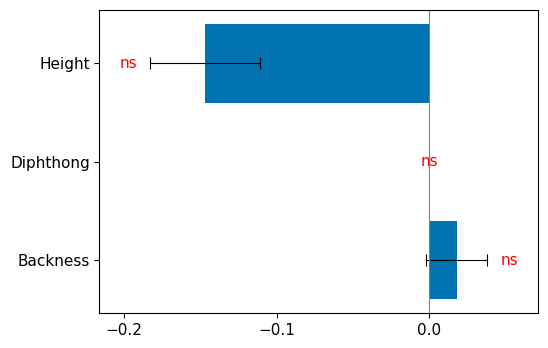

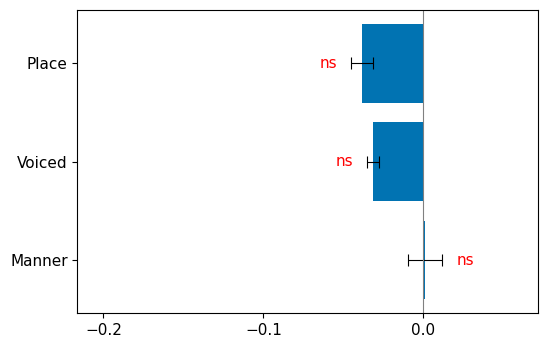

In [6]:
# Separate the phonemes into vowels and consonants
# Drop irrelevant columns for either group
v_df = phonemes_df.query("Type == 'V' and Diphthong == False")
drops = [
    "Symbol", "Type", "Place", "Manner", "Voiced", "No_Stress", "Length", "Prediction"
]
v_df = v_df.drop(columns=drops)
v_emb = embeddings[v_df.index]

c_df = phonemes_df.query("Type == 'C'")
drops = [
    "Symbol", "Type", "Height", "Backness", "Diphthong", "No_Stress", "Length", "Prediction"
]
c_df = c_df.drop(columns=drops)
c_emb = embeddings[c_df.index]

# Calculate feature importances and plot
v_results = mlem_importance(v_df, v_emb)
c_results = mlem_importance(c_df, c_emb)
mlem_phonemes(v_results, c_results)

### Figure 4

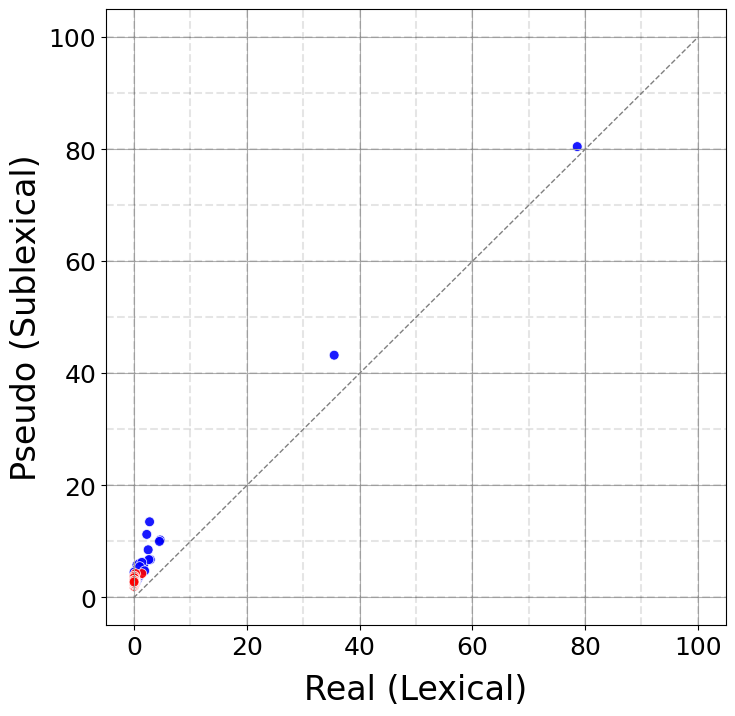

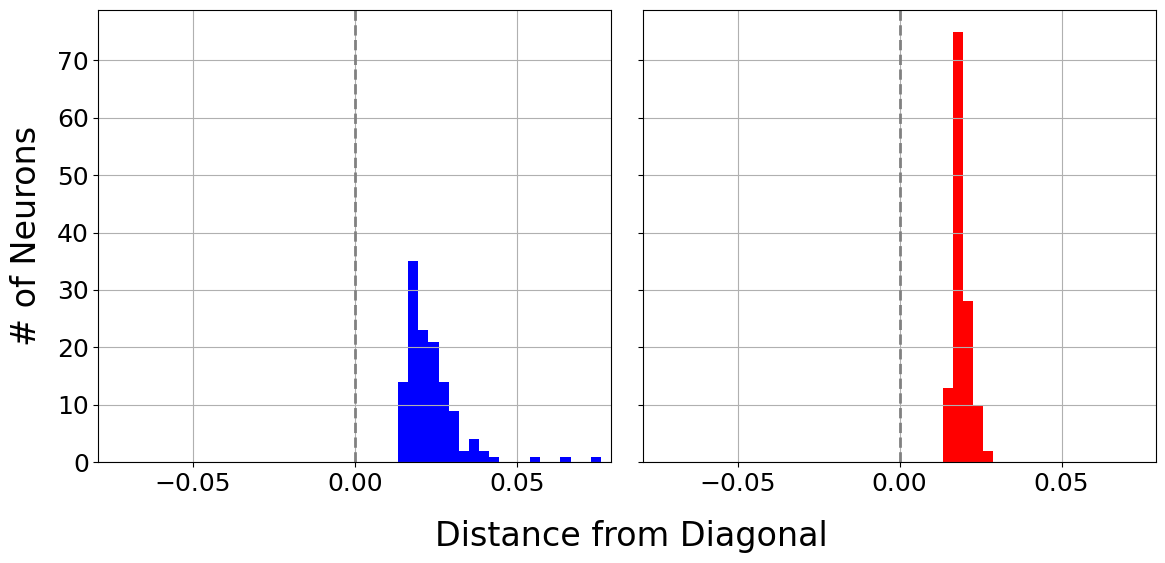

In [ ]:
from swp.test.ablations import ablate
from swp.viz.ablation import ablation_plots, importance_scatter

wfe_ablated_df, ablated_results = ablate(
    model=model,  # type: ignore
    device=device,
    test_df=wfe_df,
    test_loader=wfe_loader,
    include_stress=False,
)

ablation_plots(
    ablated_results,
    "real_accuracy",
    "pseudo_accuracy",
    "Real (Lexical)",
    "Pseudo (Sublexical)",
    "lex",
)

wfe_ablated_df.to_csv("data/wfe_ablated.csv")
ablated_results.to_csv("data/wfe_ablated_results.csv")

### Figure 5

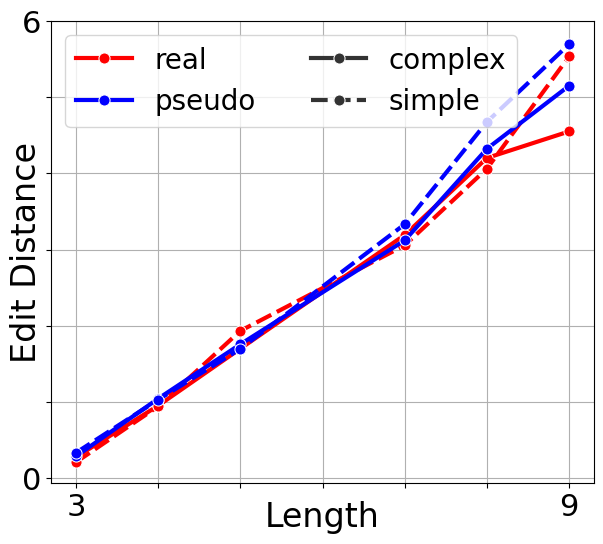

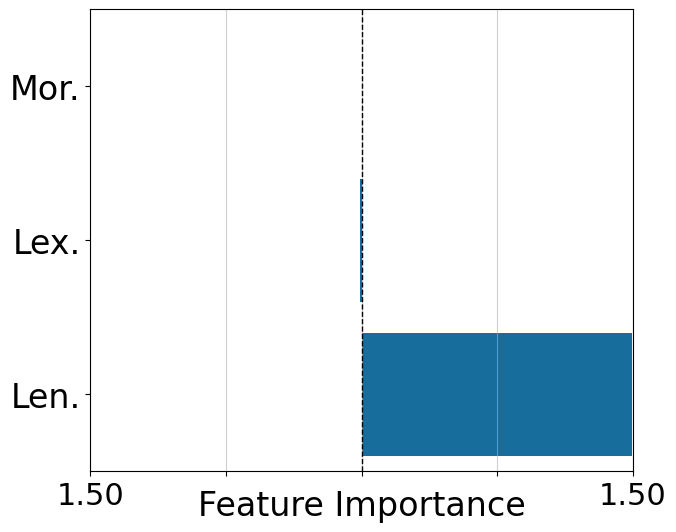

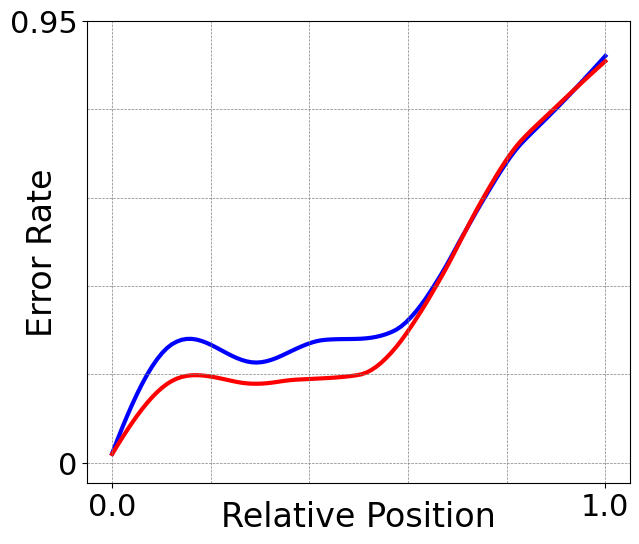

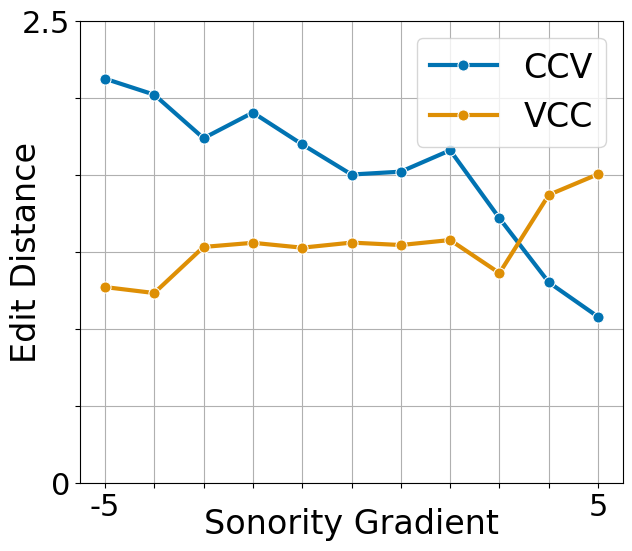

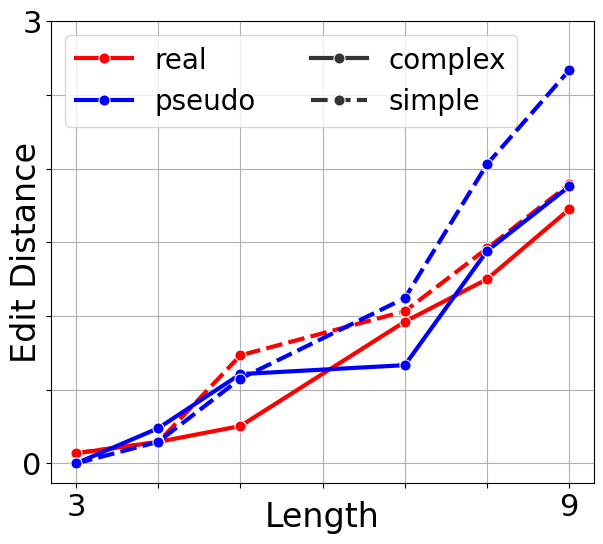

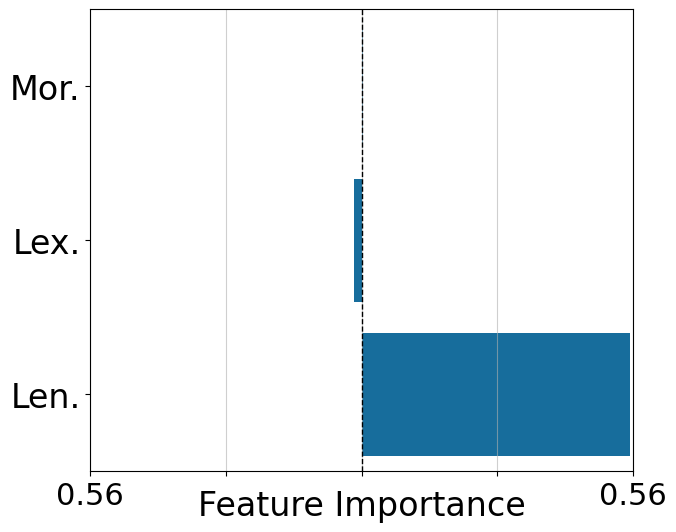

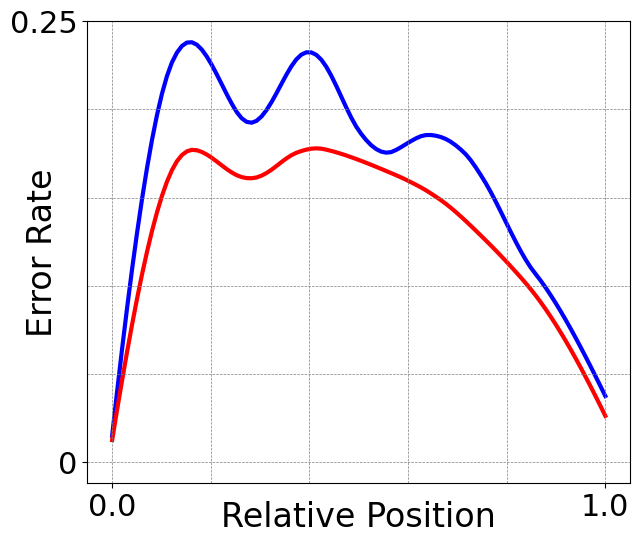

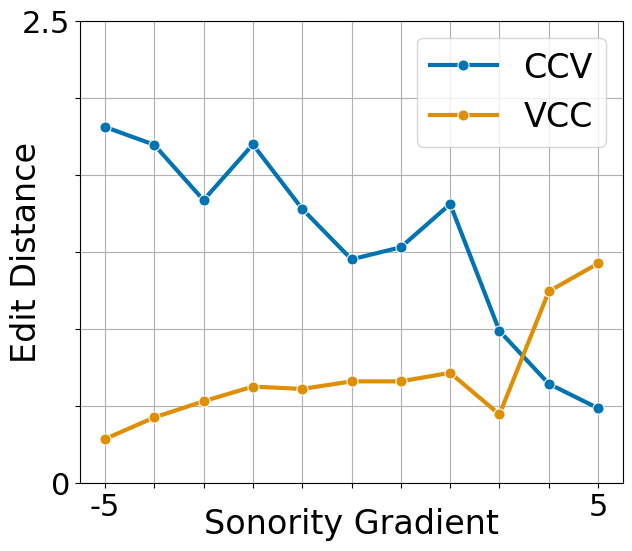

In [10]:
from swp.test.ablations import cache_lstm_weights, restore_lstm_weights, ablate_lstm_neuron
from swp.viz.test.length import plot_length_errors
from swp.viz.test.regressions import regression_plots
from swp.viz.test.position import plot_position_errors_smooth
from swp.viz.test.sonority import plot_sonority_errors

weights = cache_lstm_weights(model.encoder.recurrent)
ablate_lstm_neuron(model.encoder.recurrent, 49, 128)

wfe_49_results, _ = test(
    model=model,
    device=device,
    test_df=wfe_df,
    test_loader=wfe_loader,
)
wfe_49_results = enrich_for_plotting(wfe_49_results)
wfe_49_results.to_csv("data/wfe_49_results.csv")

ssp_49_results, _ = test(
    model=model,
    device=device,
    test_df=ssp_df,
    test_loader=ssp_loader,
)
ssp_49_results = enrich_for_plotting(ssp_49_results)
ssp_49_results.to_csv("data/ssp_49_results.csv")

plot_length_errors(wfe_49_results)
regression_plots(wfe_49_results)
plot_position_errors_smooth(wfe_49_results)
plot_sonority_errors(ssp_49_results)

# Restore the original weights
restore_lstm_weights(model.encoder.recurrent, weights)

ablate_lstm_neuron(model.encoder.recurrent, 31, 128)

wfe_31_results, _ = test(
    model=model,
    device=device,
    test_df=wfe_df,
    test_loader=wfe_loader,
)
wfe_31_results = enrich_for_plotting(wfe_31_results)
wfe_31_results.to_csv("data/wfe_31_results.csv")

ssp_31_results, _ = test(
    model=model,
    device=device,
    test_df=ssp_df,
    test_loader=ssp_loader,
)
ssp_31_results = enrich_for_plotting(ssp_31_results)
ssp_31_results.to_csv("data/ssp_31_results.csv")

plot_length_errors(wfe_31_results)
regression_plots(wfe_31_results)
plot_position_errors_smooth(wfe_31_results)
plot_sonority_errors(ssp_31_results)

### Figure 15

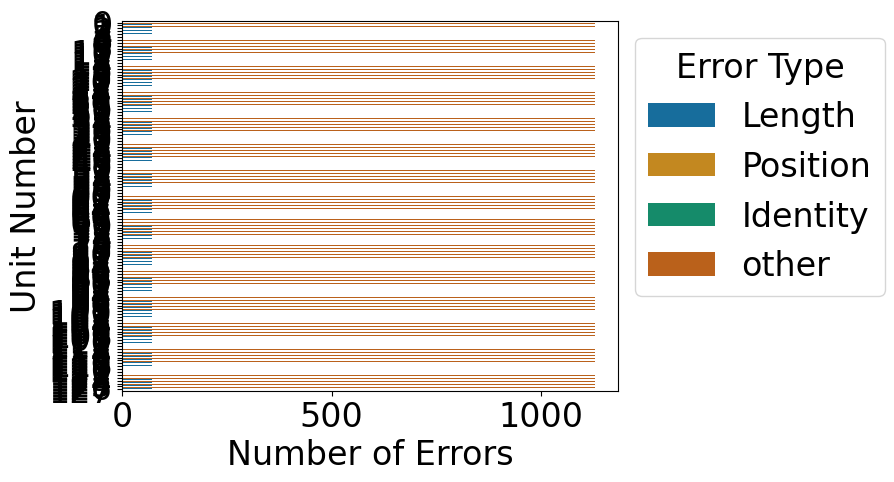

In [12]:
from collections import Counter
import pandas as pd
from ast import literal_eval
import pathlib
import seaborn as sns
from swp.utils.datasets import enrich_for_plotting

def is_early_eos(pred, gt):
    for i in range(len(pred)):
        if pred[i]=="<EOS>":
            return True
        elif pred[i]!=gt[i]:
            return False
    return False

def is_position_error(pred, gt):
    gt_count = Counter(pred)
    pred_count = Counter(gt)
    delta = len(list((gt_count-pred_count).keys())) + len(list((pred_count-gt_count).keys()))
    return delta==0

def is_identity_error(pred, gt):
    for i in range(len(pred)):
        if pred[i] in {"<EOS>", "<SOS>", "<PAD>"}:
            return False
    return True

neurons = range(128)
results = []

# cache the original weights of the LSTM
weights = cache_lstm_weights(model.encoder.recurrent)

# run the ablation test loop for neurons
for neuron in neurons:
    ablate_lstm_neuron(model.encoder.recurrent, neuron, 128)
    wfe_results, _ = test(
        model=model,
        device=device,
        test_df=wfe_df,
        test_loader=wfe_loader,
    )
    wfe_results = enrich_for_plotting(wfe_results)
    results.append(wfe_results)


df_dict = {"Unit Number" : [], "Error Type" : [], "Rate" : [], "Number of Errors" : [], "Unit Name" : []}
errors_dict = {}

for neuron, df in zip(neurons, results):
    df["Error_Rate"] = (df["Edit_Distance"] > 0).astype(int)
    errors = df["Error_Rate"].sum()
    errors_dict[neuron] = errors
    if errors >= 50:
        eos = 0
        permute = 0
        identity = 0
        other = 0

        for (index, row) in df.iterrows():
            pred = row["Prediction"]
            gt = row["No_Stress"]
            is_other = True

            if row["Error_Rate"]==1:
                if is_early_eos(pred, gt):
                    eos += 1
                    is_other = False
                if is_position_error(pred, gt):
                    permute += 1
                    is_other = False
                elif is_identity_error(pred, gt):
                    identity += 1
                    is_other = False
                if is_other:
                    other += 1
        
        for errtype, errcount in [
            ("Length", eos),
            ("Position", permute),
            ("Identity", identity),
            ("other", other)
            ]:
            df_dict["Unit Number"].append(str(neuron))
            df_dict["Error Type"].append(errtype)
            df_dict["Number of Errors"].append(errcount)
            df_dict["Rate"].append(round(errcount/errors*100))
            df_dict["Unit Name"].append(neuron)

error_df = pd.DataFrame(df_dict)
error_df = error_df.iloc[sorted(error_df.index, key=lambda k: errors_dict[error_df.loc[k, "Unit Name"]], reverse=True)]

ax = sns.barplot(error_df, y = "Unit Number", x = "Number of Errors", hue = "Error Type", orient = "h")#, dodge=False)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))